In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools

In [ ]:
#custom 4-bit quantization transform function for the MNIST images
class FourBitQuantize:
    def __call__(self, image):
        #quantize the image to 4-bit precision
        quantized_image = torch.floor(image * 15.0) / 15.0

        return quantized_image

In [ ]:
#custom 1-bit quantization transform function for the MNIST images
class OneBitQuantize:
    def __call__(self, image):
        #quantize the image to 2-bit precision(round to nearest integer 0 or 1)
        quantized_image = torch.round(image)

        return quantized_image

In [ ]:
#create a custom dataset to generate multiple augmented images
class AugmentedDataset(torch.utils.data.Dataset):
  def __init__(self, dataset, num_augments):
    self.dataset = dataset
    self.num_augments = num_augments  # Number of augmentations per original image

  def __len__(self):
    return len(self.dataset) * self.num_augments  #augmented dataset size

  def __getitem__(self, index):
    #map index to original dataset
    original_index = index // self.num_augments
    img, label = self.dataset[original_index]
    return img, label

In [ ]:
#Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((14, 14)),  # Resizes to 28x28
    transforms.ToTensor(),  # Converts to tensor
    #transforms.RandomRotation(15),  # Rotate images randomly up to ±15°
    #transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Small shifts, scaling
    #transforms.RandomCrop(14, padding=4),  # Randomly crop with padding
    #transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),  # Random erasing
    OneBitQuantize()  # Binarize images (custom function)
])

test_transform = transforms.Compose([
    transforms.Resize((14, 14)),
    transforms.ToTensor(),
    OneBitQuantize()
])



batch_size = 64
#Load MNIST dataset and apply transformations
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform) #60k images
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform) #10k images



#split the training dataset into training and validation datasets
train_size = int(0.9 * len(full_train_dataset)) #90% for training
val_size = len(full_train_dataset) - train_size #10% for validation
train_dataset, _ = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

#create a separate validation dataset with the test transforms
val_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=test_transform)

#subset only the remaining 10% of the data for validation
_, val_dataset = torch.utils.data.random_split(val_dataset, [train_size, val_size])

#make 4 augmented copies of each training image
train_dataset = AugmentedDataset(train_dataset, num_augments=4)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(dataset), size=(1,)).item()
      img, label = dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

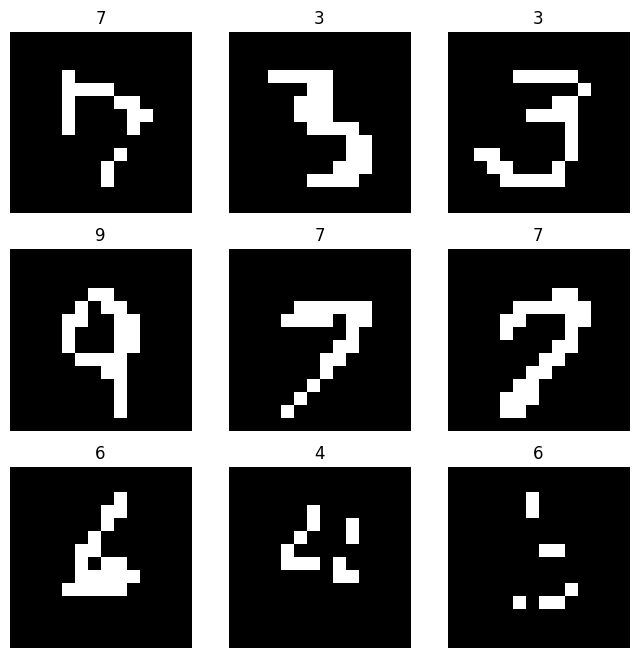

In [ ]:
show_images(train_dataset, 3, 3)

In [ ]:
activation_quantizer = torch.ao.quantization.FakeQuantize(
    observer=torch.quantization.MinMaxObserver,
    quant_min=0,
    quant_max=1,
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)

In [ ]:
weight_quantizer = torch.ao.quantization.FakeQuantize(
    observer=torch.quantization.MinMaxObserver,
    quant_min=0,
    quant_max=255,
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)

part 5 (activation 1-bit, weight 8-bit)

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)

    x = self.bn(x)  #apply batch normalization

    x = self.relu(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0), torch.tensor(0.0)) #quantize average pooling to 1 bit(0, 1)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    out = out.to(device)

    #fake quantization of activations
    out = activation_quantizer(out)

    out = out.to(device)

    return out



#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




#this sublayer is implemented by customlayer2. it takes feature maps and uses two learnable weight-matrices to simulate negative weights. The number of inputs is based on the number of sublayers used in customlayer2
class SubLayer2(nn.Module):
  def __init__(self, num_inputs, num_outputs):
    super(SubLayer2, self).__init__()

    #create 2 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(num_inputs, num_outputs))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(num_inputs, num_outputs))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)


  def forward(self, x):

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, num_outputs]
    #print("sublayer output: " + str(out.size()))

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out



class CustomLayer2(nn.Module):
  def __init__(self, num_sublayers):
    super(CustomLayer2, self).__init__()

    #calculate input per sublayer and output size per sublayer
    self.input_units_per_sublayer = int(np.ceil(15 / (num_sublayers))) * 32 #number of input units to pass to each sublayer(roudned up so last sublayer might actually take in less)
    self.output_units_per_sublayer = 2 * ((128 // num_sublayers) // 2) #number of output units from each sublayer(last sublayer will take remainder), will always be even

    #create the required number of sublayers
    self.sublayers = []
    for i in range(num_sublayers - 1):
      self.sublayers.append(SubLayer2(self.input_units_per_sublayer, self.output_units_per_sublayer))

    #last sublayer takes in whatever is left as data
    self.sublayers.append(SubLayer2(15*32 - self.input_units_per_sublayer*(num_sublayers-1), self.output_units_per_sublayer))

  def forward(self, x):
    all_outputs = []

    sublayer1_inputs_per_sublayer = int(np.ceil(15 / (len(self.sublayers))))  #how many sublayer1 outputs from customlayer1 should be passed to each sublayer2 in this layer

    for i, sublayer in enumerate(self.sublayers):
      start_index = i * sublayer1_inputs_per_sublayer
      end_index = start_index + sublayer1_inputs_per_sublayer

      #ensure last sublayer recieves remainder inputs
      if i == len(self.sublayers) - 1:
        end_index = 15

      #slice input tensor for one sublayer
      sublayer_input = x[:, start_index:end_index, :].flatten(start_dim=1)
      #print("sublayer input: " + str(sublayer_input.size()))
      all_outputs.append(sublayer(sublayer_input))

    return torch.stack(all_outputs, dim=1)  #stack all the sublayer tensors into one tensor output, size [64, num_sublayers, output_units_per_sublayer] such that num_sublayers * output_units_per_sublayer = 256 (256 units total passed to output)



class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

  def forward(self, x):
    helper = OutputLayerHelper(input_units = x.size(dim=1))
    out = helper(x)
    return out

#This layer takes in the vector of around 256 elements outputted from an even spread of CustomLayer2 sublayers, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayerHelper(nn.Module):
  def __init__(self, input_units):
    super(OutputLayerHelper, self).__init__()

    self.weighta = nn.Parameter(torch.randn(input_units, 10)) #create 2 256x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(input_units, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb


  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_QAT_Step5_CustomWidth(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, width=4):
    super(PIC_QAT_Step5_CustomWidth, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2(num_sublayers=width)
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    #print("before flattening: " + str(x.size()))
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    #print("output layer input: " + str(x.size()))
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x


In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0), torch.tensor(0.0)) #quantize average pooling to 1 bit(0, 1)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out



#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




#this sublayer is implemented by customlayer2. it takes two 128-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(128, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(128, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


#this sublayer is implemented by customlayer3. it takes two 96-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(96, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(96, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.randn(128, 10)) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(128, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(10) #batch normalization to improve accuracy (PART 5)


  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    out = self.bn(out) #apply batch normalization

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_QAT_Step5(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(PIC_QAT_Step5, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x

Part B(new architecture with more conv layers)(using PIC and EIC)

In [ ]:
class ConvLayerPIC(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayerPIC, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use sigmoid activation
    self.relu = nn.ReLU()

    #self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    #x = self.dropout(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x


class ConvLayerEIC(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayerEIC, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use sigmoid activation
    self.relu = nn.ReLU()

    #self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 8-bit(EIC has higher precision weights)
    self.conv.weight.data = torch.round(self.conv.weight.data * 255) / 255

  def forward(self, x):
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    #x = self.dropout(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 255) / 255  #ensure weights are still quantized to 8 bits

    return x


#Max pooling to downsize the image from 14x14 to 7x7
class MaxPoolLayer(nn.Module):
  def __init__(self):
    super(MaxPoolLayer, self).__init__()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0), torch.tensor(0.0)) #quantize average pooling to 1 bit(0, 1)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #self.dropout = nn.Dropout(0.5)  #dropout with the specified probability (PART 5)

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #out = self.dropout(out)
    out = out.to(device)
    #fake quantization of activations
    out = activation_quantizer(out)
    out = out.to(device)

    return out



#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 16 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()
    self.subLayer1_15 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer(based on email)
    #size: [batch size, 16, 98]
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 1, :])) #pair (2, 3) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 2, :])) #pair (4, 5) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 3, :])) #pair (6, 7) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 4, :])) #pair (8, 9) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 5, :])) #pair (10, 11) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 6, :])) #pair (12, 13) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 7, :])) #pair (14, 15) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 8, :])) #pair (0, 8) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 9, :])) #pair (1, 9) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 10, :])) #pair (2, 10) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 11, :])) #pair (3, 11) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 12, :])) #pair (4, 12) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 13, :])) #pair (5, 13) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 14, :])) #pair (6, 14) goes to sublayer 14
    all_outputs.append(self.subLayer1_15(x[:, 15, :])) #pair (7, 15) goes to sublayer 15


    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 16, 32]




#this sublayer is implemented by customlayer2. it takes two 128-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(128, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(128, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #out = self.dropout(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer2_3 = SubLayer2()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer2_3(x[:, 12:16, :].flatten(start_dim=1))) #Layer 2 sublayers 12-15(128 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.randn(128, 10)) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(128, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(10) #batch normalization to improve accuracy (PART 5)


  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    out = self.bn(out) #apply batch normalization

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out #size = [64, 10]




def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = [
    (0, 1), (2, 3), (4, 5), (6, 7),
    (8, 9), (10, 11), (12, 13), (14, 15),
    (0, 8), (1, 9), (2, 10), (3, 11),
    (4, 12), (5, 13), (6, 14), (7, 15)
  ]
  all_pairs = []
  for i, (fm1_idx, fm2_idx) in enumerate(fm_pairs):
    fm0 = x[:, fm1_idx, :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm2_idx, :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor


#Overall Architecture
class PIC_QAT_Step5_PartB(nn.Module):
  def __init__(self):
    super(PIC_QAT_Step5_PartB, self).__init__()
    self.layer0 = ConvLayerPIC(1, 6, (3,3), 1, 1)
    self.layer1 = MaxPoolLayer()
    self.layer2 = ConvLayerEIC(6, 16, (5,5), 1, 2)
    self.layer3 = MaxPoolLayer()
    self.layer4 = CustomLayer1()
    self.layer5 = CustomLayer2()
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    #x = x.to(device)
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer(PIC), output = [64, 6, 28, 28]
    x = self.layer1(x) #downsize images, output = [64, 6, 14, 14]
    x = self.layer2(x) #convolutional layer(EIC), output = [64, 16, 14, 14]
    x = self.layer3(x) #downsize images, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer4(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer5(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x


In [ ]:
class ConvLayerPIC(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayerPIC, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use sigmoid activation
    self.relu = nn.ReLU()

    #self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight.to(device))

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = x.to(device)  # Move input to device
    self.conv.weight.data = self.conv.weight.data.to(device)
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    #x = self.dropout(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x


class ConvLayerEIC(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayerEIC, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    self.bn = nn.BatchNorm2d(out_channels) #batch normalization to improve accuracy (PART 5)

    #use sigmoid activation
    self.relu = nn.ReLU()

    #self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 8-bit(EIC has higher precision weights)
    self.conv.weight.data = torch.round(self.conv.weight.data * 255) / 255

  def forward(self, x):
    x = x.to(device)  # Move input to device
    self.conv.weight.data = self.conv.weight.data.to(device)
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    #x = self.dropout(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 255) / 255  #ensure weights are still quantized to 8 bits

    return x


#Max pooling to downsize the image from 14x14 to 7x7
class MaxPoolLayer(nn.Module):
  def __init__(self):
    super(MaxPoolLayer, self).__init__()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = x.to(device)  # Move input to device
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0).to(device), torch.tensor(0.0).to(device))  #quantize average pooling to 1 bit(0, 1)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #self.dropout = nn.Dropout(0.5)  #dropout with the specified probability (PART 5)

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    x = x.to(device)  # Move input to device
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta).to(device)
    weightb_quantized = self.weightb_q(self.weightb).to(device)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #out = self.dropout(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 16 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()
    self.subLayer1_15 = SubLayer1()

  def forward(self, x):
    x = x.to(device)  # Move input to device
    #pass each possible pair of feature maps into a sublayer(based on email)
    #size: [batch size, 16, 98]
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 1, :])) #pair (2, 3) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 2, :])) #pair (4, 5) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 3, :])) #pair (6, 7) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 4, :])) #pair (8, 9) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 5, :])) #pair (10, 11) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 6, :])) #pair (12, 13) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 7, :])) #pair (14, 15) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 8, :])) #pair (0, 8) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 9, :])) #pair (1, 9) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 10, :])) #pair (2, 10) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 11, :])) #pair (3, 11) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 12, :])) #pair (4, 12) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 13, :])) #pair (5, 13) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 14, :])) #pair (6, 14) goes to sublayer 14
    all_outputs.append(self.subLayer1_15(x[:, 15, :])) #pair (7, 15) goes to sublayer 15


    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 16, 32]




#this sublayer is implemented by customlayer2. it takes two 128-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(128, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(128, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    self.dropout = nn.Dropout(0.25)  #dropout with the specified probability (PART 5)

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(32) #batch normalization to improve accuracy (PART 5)

  def forward(self, x):
    x = x.to(device)  # Move input to device
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta).to(device)
    weightb_quantized = self.weightb_q(self.weightb).to(device)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    out = self.bn(out) #apply batch normalization

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #out = self.dropout(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer2_3 = SubLayer2()

  def forward(self, x):
    x = x.to(device)  # Move input to device
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer2_3(x[:, 12:16, :].flatten(start_dim=1))) #Layer 2 sublayers 12-15(128 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.randn(128, 10)) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(128, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

    self.bn = nn.BatchNorm1d(10) #batch normalization to improve accuracy (PART 5)


  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    x = x.to(device)  # Move input to device
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta).to(device)
    weightb_quantized = self.weightb_q(self.weightb).to(device)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    out = self.bn(out) #apply batch normalization

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out #size = [64, 10]




def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = [
    (0, 1), (2, 3), (4, 5), (6, 7),
    (8, 9), (10, 11), (12, 13), (14, 15),
    (0, 8), (1, 9), (2, 10), (3, 11),
    (4, 12), (5, 13), (6, 14), (7, 15)
  ]
  all_pairs = []
  for i, (fm1_idx, fm2_idx) in enumerate(fm_pairs):
    fm0 = x[:, fm1_idx, :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm2_idx, :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor


#Overall Architecture
class PIC_QAT_Step5_PartB(nn.Module):
  def __init__(self):
    super(PIC_QAT_Step5_PartB, self).__init__()
    self.layer0 = ConvLayerPIC(1, 6, (3,3), 1, 1)
    self.layer1 = MaxPoolLayer()
    self.layer2 = ConvLayerEIC(6, 16, (5,5), 1, 2)
    self.layer3 = MaxPoolLayer()
    self.layer4 = CustomLayer1()
    self.layer5 = CustomLayer2()
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = x.to(device)  #move input to device
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer(PIC), output = [64, 6, 28, 28]
    x = self.layer1(x) #downsize images, output = [64, 6, 14, 14]
    x = self.layer2(x) #convolutional layer(EIC), output = [64, 16, 14, 14]
    x = self.layer3(x) #downsize images, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer4(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer5(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x


In [ ]:
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = [
    (0, 1), (2, 3), (4, 5), (6, 7),
    (8, 9), (10, 11), (12, 13), (14, 15),
    (0, 8), (1, 9), (2, 10), (3, 11),
    (4, 12), (5, 13), (6, 14), (7, 15)
  ]
  all_pairs = []
  for i, (fm1_idx, fm2_idx) in enumerate(fm_pairs):
    fm0 = x[:, fm1_idx, :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm2_idx, :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

x = torch.randn((16, 16, 49))
x = format_tensor(x)
x.size()

torch.Size([16, 16, 98])

In [ ]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat(model, train_loader, optimizer, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  model.to(device)
  print(device)
  best_val_accuracy = 0

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights
      with torch.no_grad():  #disable gradient tracking
        for param in model.parameters():
          #project all weights to nonnegative values
          param.data = torch.clamp(param.data, min=0)

          #quantize all weights
          #exclude conv and pooling layers from 8-bit quantization
          if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
            #param.data = weight_quantizer(param.data)
            param.data = torch.round(param.data * 256) / 256

      any_negative = False
      #check if weights are nonnegative
      for name, param in model.named_parameters():
          if torch.any(param.data < 0):
              any_negative = True
      if any_negative:
        print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    #validation phase
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if (val_accuracy >= best_val_accuracy):
      #save model
      torch.save(model.state_dict(), './pic_qat_step5_9.pth')
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    #scheduler.step()
    scheduler.step(val_loss)


  print("Training complete")

In [ ]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd(model, train_loader, optimizer, epochs=5, loss_fn=nn.CrossEntropyLoss()):
  model.to(device)
  #model = model.cuda()
  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()


      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights
      with torch.no_grad():  #disable gradient tracking
        for param in model.parameters():
          #project all weights to nonnegative values
          param.data = torch.clamp(param.data, min=0)

          #quantize all weights
          #exclude conv and pooling layers from 8-bit quantization
          if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
            #param.data = weight_quantizer(param.data)
            param.data = torch.round(param.data * 256) / 256

      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [ ]:
#save model
torch.save(model.state_dict(), './cnn_4bitquant.pth')

NameError: name 'model' is not defined

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
model_noqat = PIC_NoQAT_Step5(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model_noqat)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

TypeError: CustomLayer2.__init__() missing 1 required positional argument: 'num_sublayers'

In [ ]:
model_qat = PIC_QAT_Step5(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model_qat)

PIC_QAT_Step5(
  (layer0): ConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (layer1): AvgPoolLayer(
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (layer2): CustomLayer1(
    (subLayer1_0): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (subLayer1_1): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (subLayer1_2): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (subL

In [ ]:
model_qat = PIC_QAT_Step5_PartB()
model_qat

PIC_QAT_Step5_PartB(
  (layer0): ConvLayerPIC(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (layer1): MaxPoolLayer(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): ConvLayerEIC(
    (conv): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (layer3): MaxPoolLayer(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): CustomLayer1(
    (subLayer1_0): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (subLayer1_1): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_

In [ ]:
model_qat.eval() #model needs to be in eval mode for fusing layers
model_qat.qconfig = torch.quantization.get_default_qconfig('fbgemm')
model_qat_fused = model_qat
#model_fused = torch.ao.quantization.fuse_modules(model,[['conv1', 'flatten', 'fc']]) ---Not sure if necessary

In [ ]:
#prepare the model for quantization training, model needs to be in train
model_qat_prepared = torch.ao.quantization.prepare_qat(model_qat_fused.train())
model_qat_prepared.qconfig = torch.quantization.get_default_qconfig('fbgemm')
model_qat_prepared.to(device)
print(torch.backends.quantized.engine)  # Should output 'fbgemm' if set correctly

x86


/usr/local/lib/python3.11/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [ ]:
#test output shape
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    output = model_qat(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([64, 10])


In [ ]:
def create_sgd_optimizer(model, learning_rate, weight_decay=0.0001, momentum=0.8):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

In [ ]:
def create_adam_optimizer(model, learning_rate):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train_test_model_noqat(model, learning_rate=0.01):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  train_model_with_pgd(model, train_loader, optimizer, loss_fn=loss_fn, epochs=10)
  print("Testing accuracy: " + str(evaluate_model(model.eval(), test_loader)))

In [ ]:
def train_test_model_qat(model, learning_rate=0.01, momentum=0):
  loss_fn = nn.CrossEntropyLoss()
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimizer = create_sgd_optimizer(model, learning_rate)
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.0001) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1, min_lr=0.0001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus
  train_model_with_pgd_qat(model, train_loader, optimizer, scheduler, loss_fn=loss_fn, epochs=3)
  #convert to quantized model, model needs to be in eval
  #model_int8 = torch.ao.quantization.convert(model.eval())
  #model_int8.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  #print(torch.backends.quantized.engine)  # Should output 'fbgemm' if set correctly
  print("Testing accuracy: " + str(evaluate_model(model.eval(), test_loader)))

In [ ]:
learning_rate = 0.1

In [ ]:
train_test_model_noqat(model_noqat, learning_rate)

0.01


KeyboardInterrupt: 

In [ ]:
train_test_model_qat(model_qat_prepared, learning_rate)

cpu
[1,  2000] loss: 1.630
Epoch 1/10, Learning Rate: 0.1,
Train Loss: 0.6611, Train Accuracy: 83.59%,
Val Loss: 1.5966, Val Accuracy: 86.67%
[2,  2000] loss: 1.618
Epoch 2/10, Learning Rate: 0.1,
Train Loss: 0.6571, Train Accuracy: 84.72%,
Val Loss: 1.6005, Val Accuracy: 86.27%
[3,  2000] loss: 1.610
Epoch 3/10, Learning Rate: 0.1,
Train Loss: 0.6556, Train Accuracy: 85.39%,
Val Loss: 1.6025, Val Accuracy: 86.08%
[4,  2000] loss: 1.591
Epoch 4/10, Learning Rate: 0.010000000000000002,
Train Loss: 0.6447, Train Accuracy: 87.58%,
Val Loss: 1.5646, Val Accuracy: 89.92%
[5,  2000] loss: 1.577
Epoch 5/10, Learning Rate: 0.010000000000000002,
Train Loss: 0.6411, Train Accuracy: 88.77%,
Val Loss: 1.5525, Val Accuracy: 91.12%
[6,  2000] loss: 1.571
Epoch 6/10, Learning Rate: 0.010000000000000002,
Train Loss: 0.6396, Train Accuracy: 89.30%,
Val Loss: 1.5508, Val Accuracy: 91.28%
[7,  2000] loss: 1.566
Epoch 7/10, Learning Rate: 0.010000000000000002,
Train Loss: 0.6376, Train Accuracy: 89.79%,
V

In [ ]:
model_int8 = torch.ao.quantization.convert(model_qat_prepared.eval())

In [ ]:
evaluate_model(model_int8, test_loader)

NotImplementedError: Could not run 'aten::round.out' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::round.out' is only available for these backends: [CPU, Meta, SparseCPU, SparseCsrCPU, SparseCsrMeta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMod